In [1]:
!pip install pingouin

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler

In [3]:
pd.set_option('display.float_format', lambda x: '%.10f' % x)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Final_Project/DS304/DATA/Silver_layer/silver_data.csv')

In [6]:
df.head()

,Name,Address,Distance_to_DownTown,Distance_to_Beach,Price,Accommodation_Type,Room_Level,Point,Evaluate,Stars,...,Fitness_center,tourist_spot,eat_drink_spot,beachs,staff,convenient,clean,comfort,worthwhile,destination
0,Corgi House Danang,da nang,0.4000000000,1.7000000000,475000,phòng,superior,8.1000000000,2,0,...,0,14,3,5,8.9000000000,8.3000000000,8.6000000000,8.3000000000,8.8000000000,9.4000000000
1,Ngoc Bich hotel,da nang,1.8000000000,0.0000000000,242338,phòng,superior,8.0000000000,2,3,...,0,14,3,5,8.3000000000,7.8000000000,8.0000000000,7.9000000000,8.3000000000,8.7000000000
2,La Belle Vie Boutique Hotel,da nang,1.3000000000,2.4000000000,450000,phòng,superior,8.9000000000,3,4,...,1,16,3,5,8.7000000000,8.7000000000,8.9000000000,8.9000000000,9.1000000000,8.7000000000
3,LaDa's House Da Nang,da nang,0.0000000000,2.4000000000,806841,phòng,deluxe,9.0000000000,4,0,...,0,14,3,5,9.5000000000,9.0000000000,9.2000000000,9.2000000000,9.2000000000,9.2000000000
4,Dana Boutique Hotel & Apartment,da nang,1.4000000000,0.0000000000,524200,studio,khác,8.8000000000,3,4,...,0,13,3,5,9.0000000000,8.9000000000,9.1000000000,9.0000000000,8.9000000000,8.9000000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  3904 non-null   object 
 1   Address               3904 non-null   object 
 2   Distance_to_DownTown  3904 non-null   float64
 3   Distance_to_Beach     3904 non-null   float64
 4   Price                 3904 non-null   int64  
 5   Accommodation_Type    3904 non-null   object 
 6   Room_Level            3904 non-null   object 
 7   Point                 3904 non-null   float64
 8   Evaluate              3904 non-null   int64  
 9   Stars                 3904 non-null   int64  
 10  Rates_Quantity        3904 non-null   int64  
 11  view_to_beach         3904 non-null   int64  
 12  view_to_city          3904 non-null   int64  
 13  view_to_mountain      3904 non-null   int64  
 14  view_to_river         3904 non-null   int64  
 15  eaves                

Vì thuộc tính Evaluate được quyết định bởi thuộc tính target là Point nên ta sẽ tiến hành loại bỏ thuộc tính này

In [8]:
df.drop(columns=['Evaluate'], inplace=True)

In [9]:
binary_cols = ['view_to_beach', 'view_to_city', 'view_to_mountain',
               'view_to_river', 'eaves', 'pool', 'parking', 'airport_shuttle',
               'free_breakfast', 'spa', 'bar', 'Fitness_center']

categorical_cols = ['Address', 'Accommodation_Type', 'Room_Level']

continous_cols = ['Distance_to_DownTown', 'Distance_to_Beach', 'Price',
                  'Stars', 'Rates_Quantity', 'tourist_spot',
                  'eat_drink_spot', 'beachs', 'staff', 'convenient',
                  'clean', 'comfort', 'worthwhile', 'destination']

# Phân phối Điểm đánh giá của khách hàng (Point)

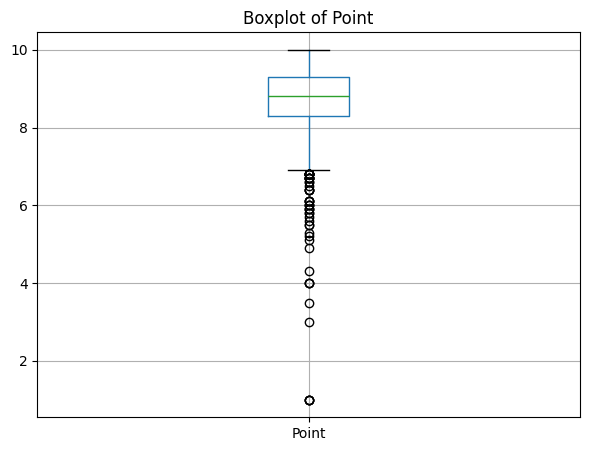

In [10]:
plt.figure(figsize=(7, 5))
df.boxplot(column='Point')
plt.title('Boxplot of Point')
plt.show()

# Kiểm tra độ tương quan

## Giữa các thuộc tính với nhau (check đa cộng tuyến)

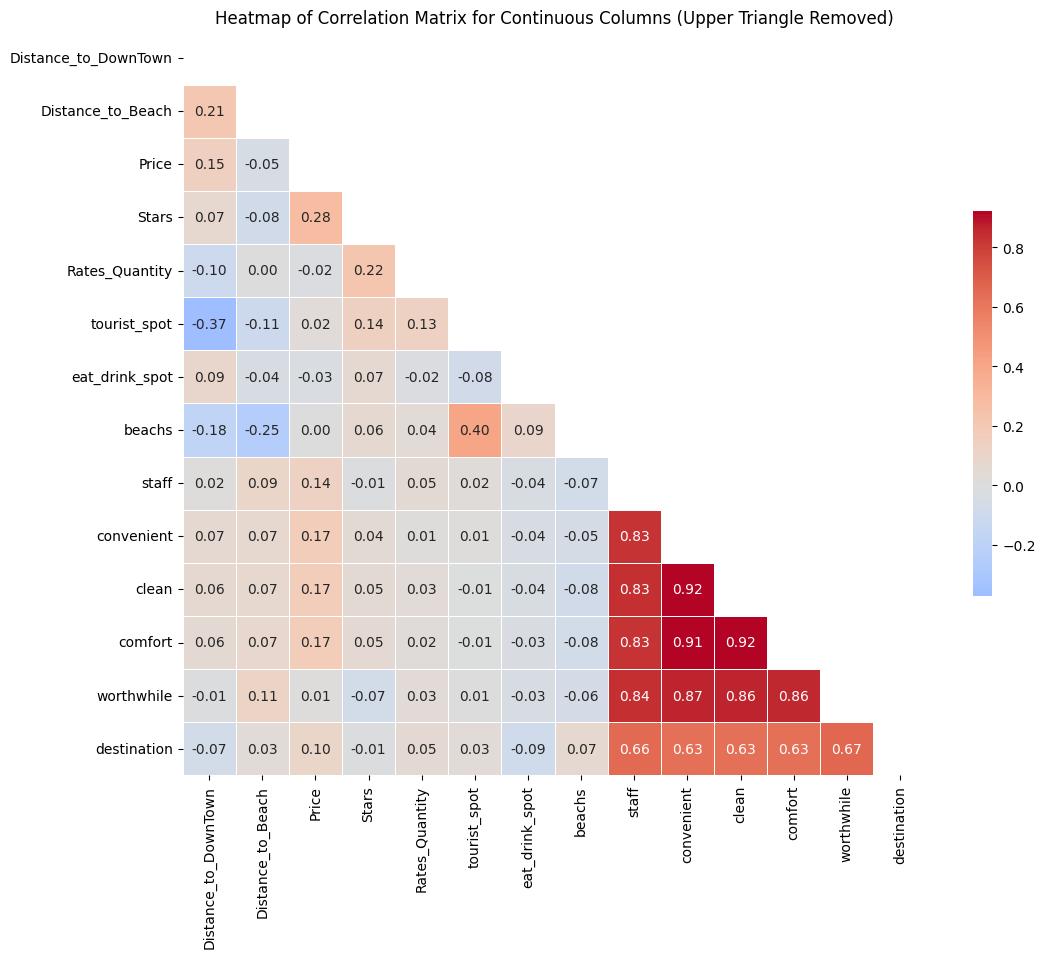

In [11]:
_continous = df[continous_cols]
_continous_matrix = _continous.corr()

# Trực quan hóa ma trận tương quan
mask = np.triu(np.ones_like(_continous_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(_continous_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Heatmap of Correlation Matrix for Continuous Columns (Upper Triangle Removed)')
plt.show()

In [12]:
# Xóa các thuộc tính bị đa cộng tuyến
cols_to_drop = ['staff', 'convenient', 'comfort', 'worthwhile']
continous_cols = [col for col in continous_cols if col not in cols_to_drop]
df.drop(columns=cols_to_drop, inplace=True)

## Giữa các thuộc tính với điểm hài lòng của khách hàng

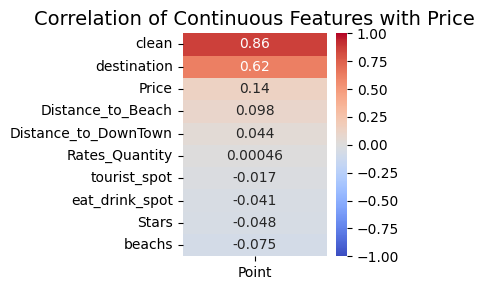

In [36]:
_target_correlation = df[continous_cols + ['Point']].corr()['Point'].drop('Point')
_target_correlation = _target_correlation.sort_values(ascending=False)

# Trực quan hóa
plt.figure(figsize=(4, 3))
sns.heatmap(_target_correlation.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Correlation of Continuous Features with Price', fontsize=14)
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.show()

# Kiểm định two-sample t test đối với các cột binary

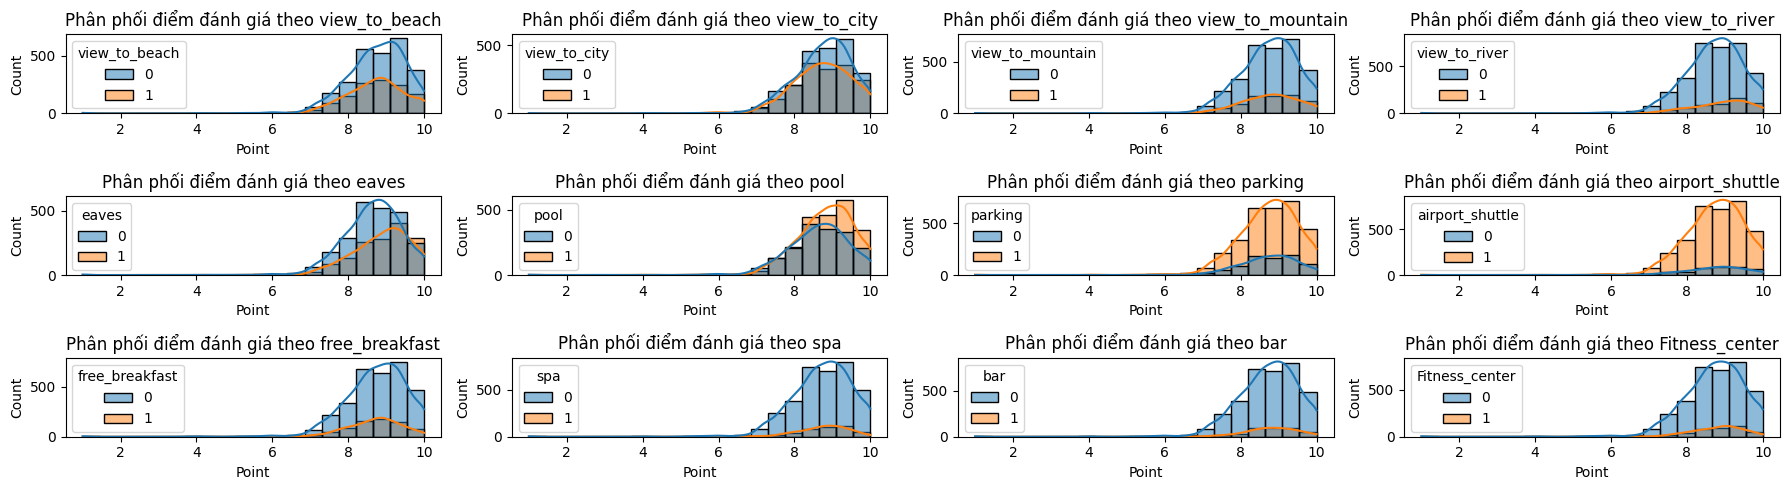

In [14]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 5))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    ax = axes[i]
    sns.histplot(data=df, x='Point', hue=col, kde=True, bins=20, ax=ax)
    ax.set_title(f'Phân phối điểm đánh giá theo {col}')

plt.tight_layout()
plt.show()

In [15]:
# drop để phân phối chuẩn
df = df[df['Point'] >= 6]

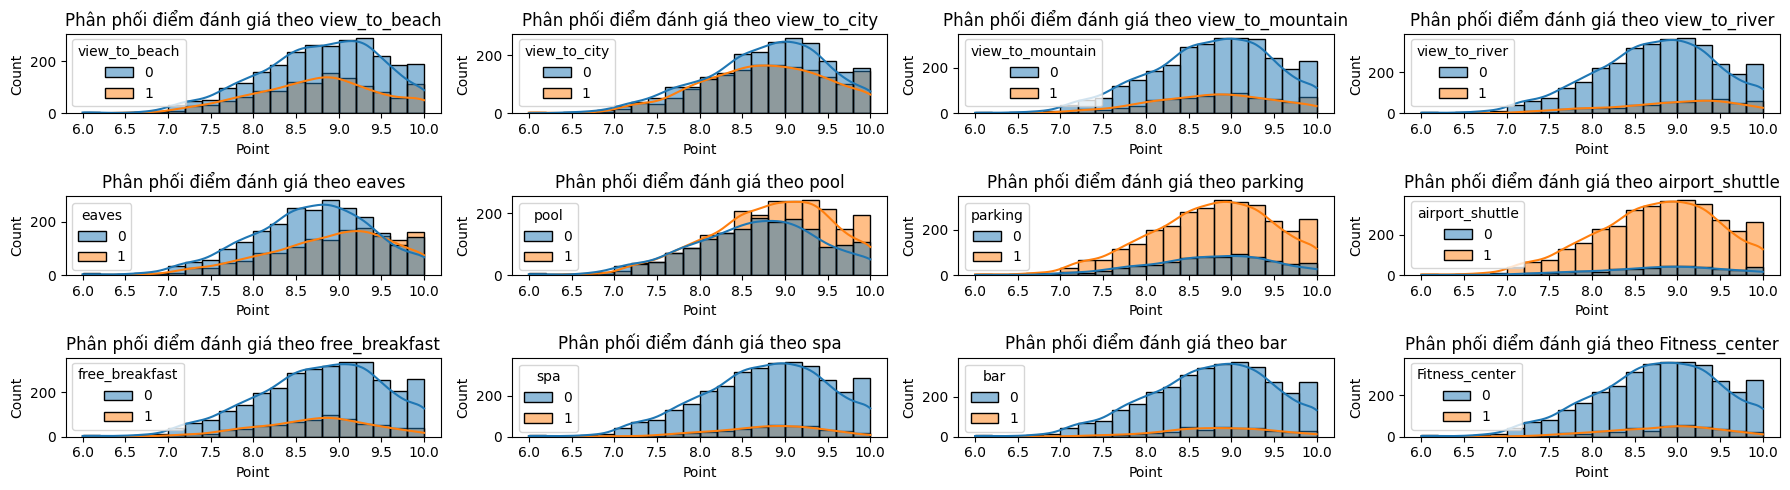

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 5))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    ax = axes[i]
    sns.histplot(data=df, x='Point', hue=col, kde=True, bins=20, ax=ax)
    ax.set_title(f'Phân phối điểm đánh giá theo {col}')

plt.tight_layout()
plt.show()

/tmp/ipython-input-17-4218039581.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
/tmp/ipython-input-17-4218039581.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
/tmp/ipython-input-17-4218039581.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
/tmp/ipython-input-17-4218039581.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dat

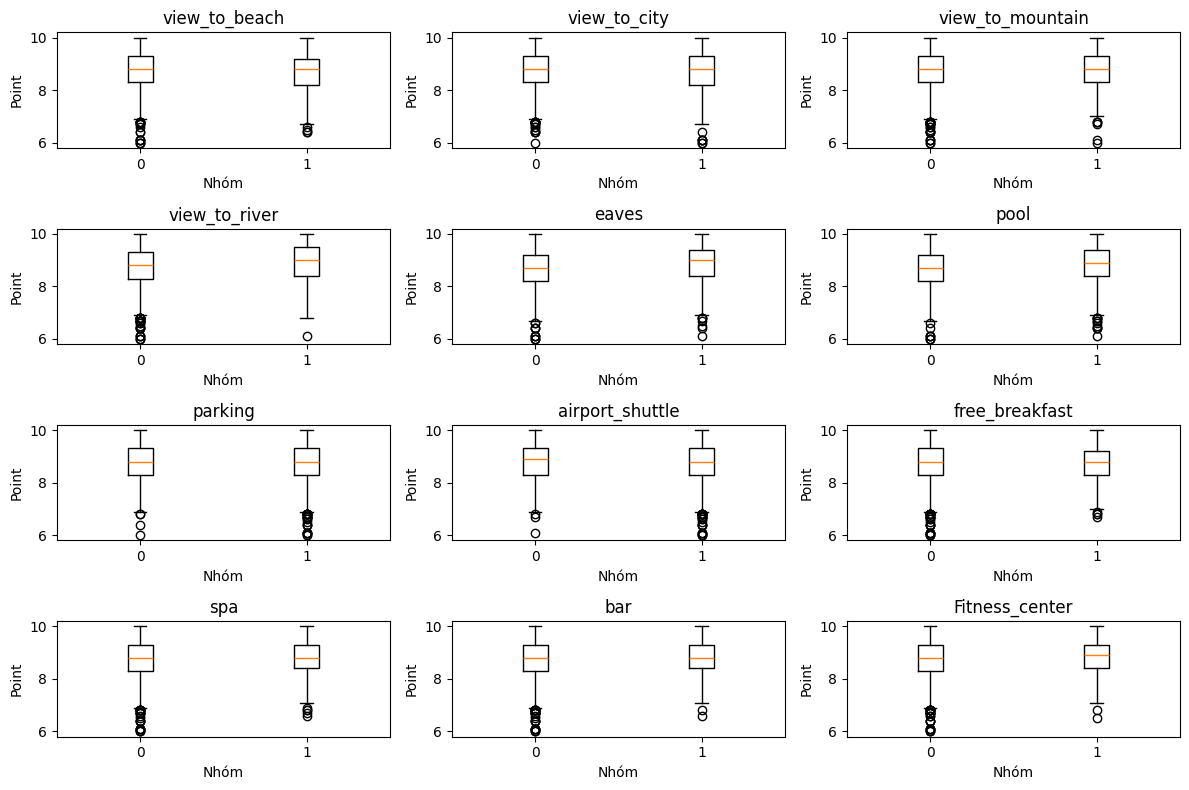

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
axes = axes.flatten()

# Vẽ từng boxplot
for i, col in enumerate(binary_cols):
    ax = axes[i]
    data0 = df[df[col] == 0]['Point']
    data1 = df[df[col] == 1]['Point']

    ax.boxplot([data0, data1], labels=['0', '1']);
    ax.set_title(col)
    ax.set_xlabel('Nhóm')
    ax.set_ylabel('Point')

for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();

In [18]:
results = []
alpha = 0.05

for col in binary_cols:
    try:
        test_result = pg.ttest(x=df[df[col] == 1]['Point'],
                               y=df[df[col] == 0]['Point'],
                               alternative='two-sided')
        test_result['column'] = col
        test_result['significant'] = test_result['p-val'] < alpha
        results.append(test_result)
    except Exception as e:
        print(f"Không thể kiểm định với cột {col}: {e}")

# Gộp tất cả kết quả lại thành 1 DataFrame
ttest_results = pd.concat(results, ignore_index=True)

# In ra kết quả
display(ttest_results[['column', 'T', 'dof', 'p-val', 'CI95%', 'significant']])

/tmp/ipython-input-18-3264358974.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ttest_results = pd.concat(results, ignore_index=True)


,column,T,dof,p-val,CI95%,significant
0,view_to_beach,-1.5522248735,2424.7014199000,0.1207389322,"[-0.09, 0.01]",False
1,view_to_city,-1.0642173101,3524.5409550699,0.2873031700,"[-0.07, 0.02]",False
2,view_to_mountain,0.7174798110,1238.9116041774,0.4732133426,"[-0.04, 0.08]",False
3,view_to_river,5.5731049729,753.3236178350,0.0000000349,"[0.12, 0.25]",True
4,eaves,9.5855935045,3124.7061793496,0.0000000000,"[0.18, 0.28]",True
5,pool,7.2627632163,3501.3822259640,0.0000000000,"[0.13, 0.22]",True
6,parking,0.1130070218,1268.6778284310,0.9100428667,"[-0.05, 0.06]",False
7,airport_shuttle,-1.2698464183,479.6488249024,0.2047550474,"[-0.13, 0.03]",False
8,free_breakfast,-1.5056985256,1114.1377928581,0.1324280273,"[-0.1, 0.01]",False
9,spa,1.0182167456,560.9800333601,0.3090138850,"[-0.03, 0.1]",False


In [19]:
# Xóa các cột dạng binary không có ý nghĩa thống kê
binary_cols_to_drop = ['view_to_beach', 'view_to_city', 'view_to_mountain', 'view_to_river',
                        'parking', 'airport_shuttle', 'free_breakfast', 'spa']
binary_cols = [col for col in binary_cols if col not in binary_cols_to_drop]
df.drop(columns=binary_cols_to_drop, inplace=True)

# Kiểm định ANOVA đối với các cột categorical


In [20]:
for col in categorical_cols:
    print(f"{col} có {df[col].nunique()}")

Address có 11
Accommodation_Type có 9
Room_Level có 7


In [21]:
anova_results = []
alpha = 0.05

for col in categorical_cols:
    try:
        aov = pg.anova(dv='Point', between=col, data=df, detailed=True)
        aov = aov[aov['Source'] != 'Within'].copy()
        aov['column'] = col
        aov['significant'] = aov['p-unc'] < alpha
        anova_results.append(aov)

    except Exception as e:
        print(f"Không thể kiểm định ANOVA hoặc posthoc với cột {col}: {e}")

# Gộp kết quả ANOVA
anova_df = pd.concat(anova_results, ignore_index=True)

# In kết quả ANOVA
print("Kết quả kiểm định ANOVA")
display(anova_df[['column', 'SS', 'F', 'DF', 'p-unc', 'np2', 'significant']])

Kết quả kiểm định ANOVA


,column,SS,F,DF,p-unc,np2,significant
0,Address,184.1544531931,38.0065576075,10,0.0000000000,0.0894258146,True
1,Accommodation_Type,78.9056708633,19.2842261083,8,0.0000000000,0.0383167703,True
2,Room_Level,31.6557957671,10.0802233332,6,0.0000000000,0.0153721253,True


## Post-hoc test (Tukey HSD)

In [22]:
# thực hiện post-hoc test với cột 'Accomodation_type' và 'Room_level'
ordinal_cols = ['Accommodation_Type', 'Room_Level']
posthoc_results = []
alpha = 0.05

for col in ordinal_cols:
    try:
        tukey = pg.pairwise_tukey(dv='Point', between=col, data=df)
        tukey['column'] = col
        tukey['combine'] = tukey['p-tukey'] >= alpha # gộp lại nếu p-val >= 0.05, giữ lại nếu p-val < 0.05
        posthoc_results.append(tukey)

    except Exception as e:
        print(f"Không thể thực hiện post-hoc với cột {col}: {e}")

# Gộp kết quả posthoc
posthoc_df = pd.concat(posthoc_results, ignore_index=True)

# In kết quả post-hoc
print("Kết quả post-hoc")
display(posthoc_df[['column', 'A', 'B', 'p-tukey', 'diff', 'se', 'T', 'combine']])

/usr/local/lib/python3.11/dist-packages/pingouin/effsize.py:802: RuntimeWarning: Degrees of freedom <= 0 for slice
  poolsd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Kết quả post-hoc


,column,A,B,p-tukey,diff,se,T,combine
0,Accommodation_Type,biệt thự,bungalow,0.0152877004,0.3589391539,0.1033617811,3.4726486920,False
1,Accommodation_Type,biệt thự,căn hộ,0.0000001772,0.2862673558,0.0488308584,5.8624272655,False
2,Accommodation_Type,biệt thự,khác,0.0727447313,0.4347826087,0.1462269494,2.9733411701,True
3,Accommodation_Type,biệt thự,phòng,0.0000000000,0.4885531315,0.0438191355,11.1493101425,False
4,Accommodation_Type,biệt thự,resort,0.9999170261,0.3501672241,0.7163628251,0.4888126684,True
5,Accommodation_Type,biệt thự,studio,0.0059110230,0.3020540165,0.0808438508,3.7362645814,False
6,Accommodation_Type,biệt thự,suite,0.0000216662,0.3330549246,0.0666760317,4.9951221755,False
7,Accommodation_Type,biệt thự,villa,0.9992860219,0.2101672241,0.3224959038,0.6516895923,True
8,Accommodation_Type,bungalow,căn hộ,0.9982111211,-0.0726717981,0.0982188333,-0.7398967759,True
9,Accommodation_Type,bungalow,khác,0.9999573137,0.0758434548,0.1692477686,0.4481208550,True


In [23]:
# Accommodation_Type grouping
group_a = ['biệt thự', 'bungalow', 'resort', 'villa', 'studio', 'khác']
group_b = ['phòng']
group_c = ['căn hộ']
group_d = ['suite']

df['Accommodation_Type_Grouped'] = df['Accommodation_Type'].map(
    lambda x: 'Group_A' if x in group_a else 'Group_B' if x in group_b else 'Group_C' if x in group_c else 'Group_D'
)

# Room_Level grouping
level_high = ['deluxe', 'executive', 'gia đình', 'premium', 'superior']
level_other = ['khác']
level_basic = ['tiêu chuẩn']

df['Room_Level_Grouped'] = df['Room_Level'].map(
    lambda x: 'Level_High' if x in level_high else 'Level_Other' if x in level_other else 'Level_Basic'
)

In [24]:
for col in ['Accommodation_Type_Grouped', 'Room_Level_Grouped']:
  print(df[col].nunique())

4
3


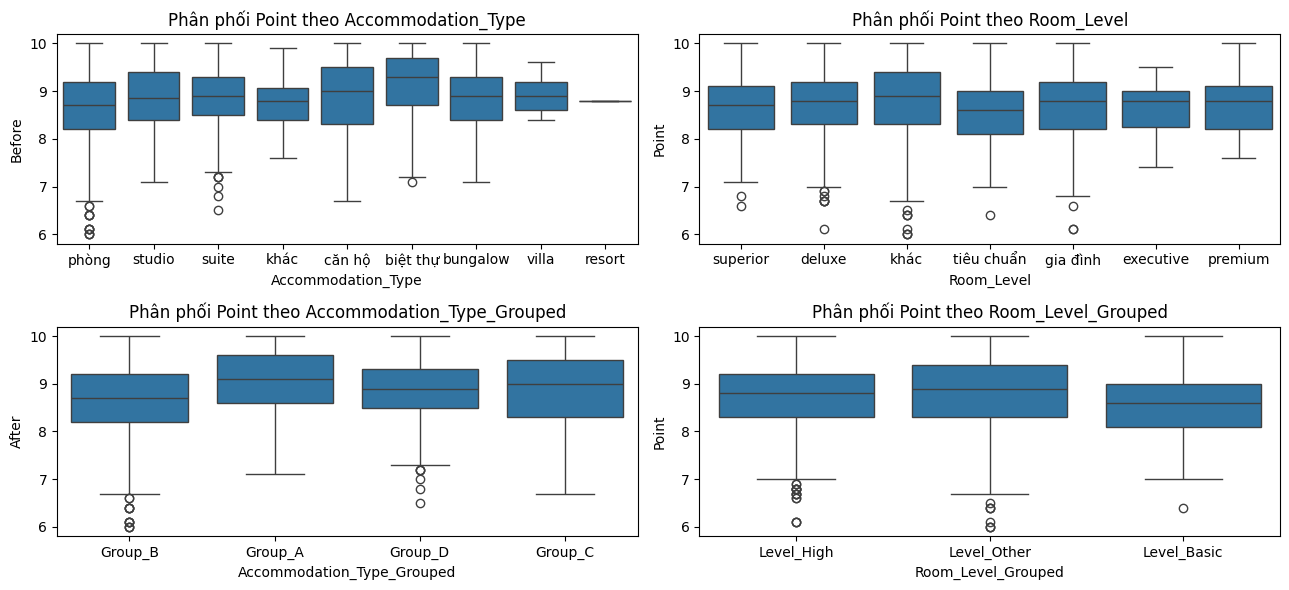

In [25]:
bs_cols = ['Accommodation_Type', 'Room_Level', 'Accommodation_Type_Grouped', 'Room_Level_Grouped']
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

axes = axes.flatten()

for i, col in enumerate(bs_cols):
    # Use the flattened axes array
    sns.boxplot(x=col, y='Point', data=df, ax=axes[i])
    axes[i].set_title(f'Phân phối Point theo {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x')
axes[0].set_ylabel('Before')
axes[2].set_ylabel('After')

plt.tight_layout()
plt.show()

In [26]:
df['Accommodation_Type'] = df['Accommodation_Type_Grouped']
df['Room_Level'] = df['Room_Level_Grouped']
df.drop(columns=['Accommodation_Type_Grouped', 'Room_Level_Grouped'], inplace=True)

# VIF - Check Multicollinearity sau Feature Selection

In [27]:
# check các cột chứu giá trị số
_col_check_vif = binary_cols + continous_cols
X = df[_col_check_vif]
X = add_constant(X)

# Tính VIF
vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_df)

,Feature,VIF
0,const,737.7557568161
1,eaves,1.0797381355
2,pool,1.2959384450
3,bar,1.1493711273
4,Fitness_center,1.1700017040
5,Distance_to_DownTown,1.2964662019
6,Distance_to_Beach,1.1242081259
7,Price,1.1734950486
8,Stars,1.5173318043
9,Rates_Quantity,1.1007499746


# Encode & Scale Data

In [28]:
# xóa cột Name không có giá trị
df.drop(columns=['Name'], inplace=True)

In [29]:
# Onehot Encoding các cột Object
df_onehot = pd.get_dummies(df[['Address', 'Accommodation_Type', 'Room_Level']], drop_first=True)
df = pd.concat([df, df_onehot], axis=1)
df.drop(columns=['Address', 'Accommodation_Type', 'Room_Level'], inplace=True)

In [30]:
# StandardScaler
_sclale_cols = ['Distance_to_DownTown', 'Distance_to_Beach', 'Price',
                  'Stars', 'Rates_Quantity', 'tourist_spot',
                  'eat_drink_spot', 'beachs']
scaler = StandardScaler()
df[_sclale_cols] = scaler.fit_transform(df[_sclale_cols])

In [31]:
df.columns

Index(['Distance_to_DownTown', 'Distance_to_Beach', 'Price', 'Point', 'Stars',
       'Rates_Quantity', 'eaves', 'pool', 'bar', 'Fitness_center',
       'tourist_spot', 'eat_drink_spot', 'beachs', 'clean', 'destination',
       'Address_da nang', 'Address_dao cat ba', 'Address_dong hoi',
       'Address_ha long', 'Address_hoi an', 'Address_mui ne',
       'Address_nha trang', 'Address_phu quoc', 'Address_quy nhon',
       'Address_vung tau', 'Accommodation_Type_Group_B',
       'Accommodation_Type_Group_C', 'Accommodation_Type_Group_D',
       'Room_Level_Level_High', 'Room_Level_Level_Other'],
      dtype='object')

In [32]:
# Constrain Type
bool_columns = df.select_dtypes(include=['bool']).columns  # Xác định các cột kiểu bool
df[bool_columns] = df[bool_columns].astype(int)  # Chuyển thành int

In [33]:
# Xuất file gold_data
df.to_csv('gold_data.csv', index=False, encoding='utf-8-sig')